In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d": 'true',
        'use_fresnel_scaling': 'true',
        "N": 16384 * 16384,
        "nx": 16384,
        "ny": 16384,
        "dx": 8.5e-8,          # 85 nm
        "z_detector": 4.0,     # 探测器位置 4.0 m
        "detector_size": 0.85e-3,       # 探测器 0.85 mm
        "detector_size_y": 0.85e-3,
        "detector_pixel_size_x": 2e-7, # 像素可调
        "detector_pixel_size_y": 2e-7,
        "chunk_size": 2*1024*1024*1024 // 16,
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [1, 100001],
        "x_range": [-1e-6, 1e-6],
        "y_range": [-1e-6, 1e-6],
        "z": 0.0,
        "nr_source_points": 1,
        "seed": 1,
        "spectrum": "/mnt/d/rave-sim-main/rave-sim-main/spectrum/spectrum_microX.h5",
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 1.0,            # 样品位于 1.0 m
            "pixel_size_x": 5e-8,      # 样品内部高分辨率
            "pixel_size_y": 5e-8,
            "pixel_size_z": 5e-8,
            "grid_path": "/mnt/d/rave-sim-main/rave-sim-main/grid/100um_half_hollow_millisphere.npy",
            "materials": [["H", 0.255]],
            "x_positions": [0],
            "y_positions": [0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  268435456


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-06-13 02:07:54,012 INFO: Setting up simulation
2026-06-13 02:07:54,013 INFO: 2D mode: nx=16384, ny=16384, dx=8.500e-08, dy=8.500e-08, detector=(8.500e-04 x 8.500e-04) m
2026-06-13 02:08:33,791 INFO: Fresnel scaling enabled, skipping source→sample Nyquist check
2026-06-13 02:09:38,832 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260613_020834005705


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-06-13 02:10:10.795] [info] Detector 2D mode
[2026-06-13 02:10:10.797] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/06/20260613_020834005705/00000000
[2026-06-13 02:10:10.797] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-06-13 02:10:10.797] [info] GPU memory required for wavefield: 2048 MB
[2026-06-13 02:10:11.500] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-06-13 02:10:11.589] [info]   Using Fresnel scaling (z_src=0, avoiding analytical propagation)
[2026-06-13 02:10:11.605] [info]   Fresnel params: z_eff=7.500000e-01, M=4.00x
[2026-06-13 02:10:25.161] [info]   Number of optical elements: 1
[2026-06-13 02:20:39.018] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-06-13 02:20:39.019] [info]   effective_pixel_size_x=5e-08, effective_pixel_size_y=5e-08, ds_z=0.75
[2026-06-13 02:20:39.659] [info] 2D Simulation finished in 677.634619137 seconds


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [11:01<00:00, 661.36s/it]


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1],wf.shape[2])

nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 4250 4250


[[7.3435537e-15 0.0000000e+00 7.3608561e-15 ... 7.3893553e-15
  7.3768176e-15 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [7.3608434e-15 0.0000000e+00 7.3758130e-15 ... 7.3924140e-15
  7.3829992e-15 0.0000000e+00]
 ...
 [7.3893875e-15 0.0000000e+00 7.3924656e-15 ... 7.3716388e-15
  7.3752040e-15 0.0000000e+00]
 [7.3768345e-15 0.0000000e+00 7.3830314e-15 ... 7.3751896e-15
  7.3750693e-15 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]]


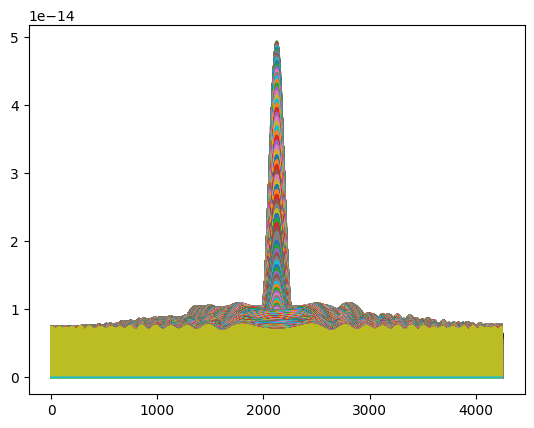

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

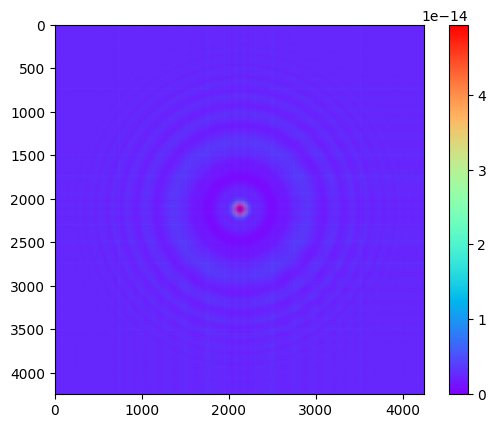

In [10]:
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()

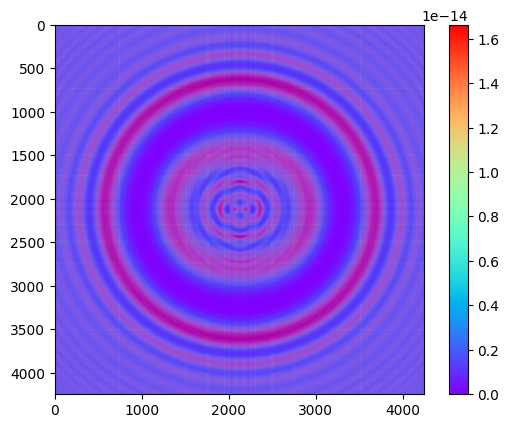

In [10]:
#non sphere 1 shot,fresnel on
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()

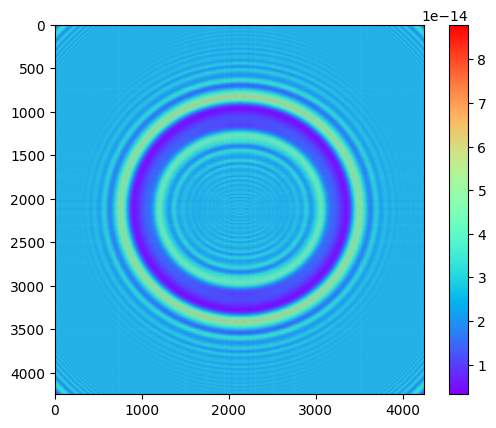

In [11]:
#non sphere 1 shot,fresnel off
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()

In [11]:
from contextlib import redirect_stdout
with open('output_3d_test_f_DT_nonsphere_260611.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            for j in range(len(wf[0][i])):
                print(wf[0][i][j])
            print('\n')

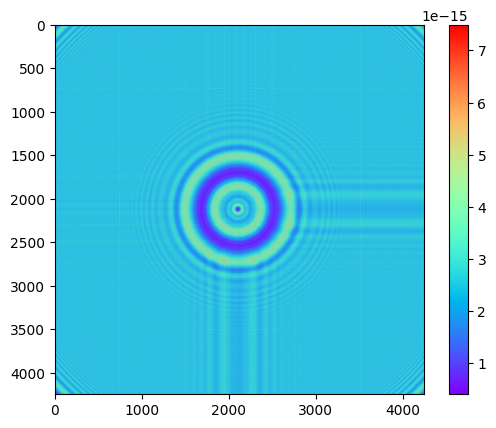

In [12]:
# one single shot,fresnel off
plt.imshow(wf[0],cmap='rainbow')
plt.colorbar()
plt.show()